In [1]:
# Audio-apparaten controleren

import sounddevice as sd

# Toon de lijst met alle beschikbare audio-apparaten
print("Lijst met gedetecteerde apparaten:")
print(sd.query_devices())

Lijst met gedetecteerde apparaten:
   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Microphone Array (Realtek(R) Au, MME (2 in, 0 out)
   2 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  3 Headphones (JBL TUNE BEAM), MME (0 in, 2 out)
   4 Speakers (Realtek(R) Audio), MME (0 in, 8 out)
   5 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   6 Microphone Array (Realtek(R) Audio), Windows DirectSound (2 in, 0 out)
   7 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
   8 Headphones (JBL TUNE BEAM), Windows DirectSound (0 in, 2 out)
   9 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 8 out)
  10 Speakers (Realtek(R) Audio), Windows WASAPI (0 in, 2 out)
  11 Headphones (JBL TUNE BEAM), Windows WASAPI (0 in, 2 out)
  12 Microphone Array (Realtek(R) Audio), Windows WASAPI (2 in, 0 out)
  13 Headphones 1 (Realtek HD Audio 2nd output with SST), Windows WDM-KS (0 in, 2 out)
  14 Headphones 2 (Realtek HD Audio 2nd output with SST), Windows WDM-K

In [622]:
# Cel 1
import sounddevice as sd
import soundfile as sf
import os
import numpy as np
import time

map= int(input('0 = zonder gordijnen; 1 = met gordijnen: '))
grid= input('grid: ')

# Audioconfiguratie
Rate = 44100       # Samplefrequentie (CD-kwaliteit, legt vast tot ~22kHz)
duration = 3      # Opnameduur in seconden
Channels = 1       # Aantal kanalen (1=mono, 2=stereo)
output_file = rf"D:\project\{map}\{grid[0]}\meting_{grid[1]}.wav"  # Naam van het doelbestand
map_direct= rf"D:\project\{map}\{grid[0]}"
#output_file= r"C:\Users\huubz\OneDrive\project 1.3\python files\data\test.wav"

# Controle op bestaand bestand
if os.path.exists(output_file):
    keuze = input('Wilt u het bestand overschrijven?')
    if keuze != '':
        raise KeyboardInterrupt('bestand overschrijven niet toegestaan')

if os.path.exists(map_direct) == False:
    raise LookupError('bestands locatie bestaat niet')

# wav file recorden
print("Start opname...")
recording = sd.rec(
    int(duration * Rate), 
    samplerate = Rate, 
    channels = Channels, 
    dtype = 'float32',
    device = None     # Pakt automatisch het apparaat met het > pijltje
)
sd.wait()
print("Opname gestopt")

# Opslaan
sf.write(output_file, recording, Rate)
print("Opname succesvol opgeslagen")

# Clipping-detectie (kijkt naar absolute pieken boven 0.99)
if np.any(np.abs(recording) >= 0.99):
    print("⚠️⚠️ Clipping gedetecteerd")
else:
    print("Geen clipping gedetecteerd")

Start opname...
Opname gestopt
Opname succesvol opgeslagen
Geen clipping gedetecteerd


Nagalmtijd:
0.5201586997299786
Tijd begin:
0.6647669351206241
Tijd eind:
1.0063341456446369
Nagalmtijd is succesvol genoteerd


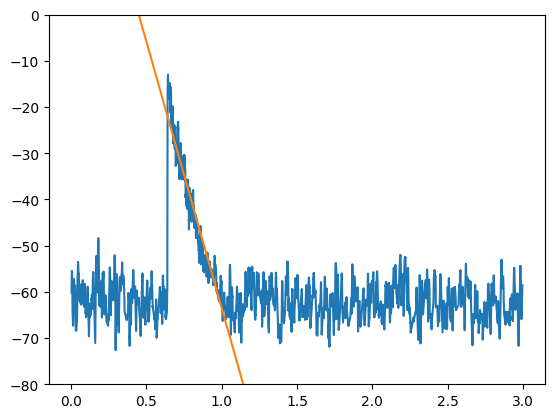

In [ ]:
# cell 2

import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import wavfile
from scipy.stats import linregress
import os

# calibratie constante toevoegen
c_kalibratie= -4 

# bestand van vorige cel ophalen
sampling_rate, audio_data = wavfile.read(output_file)

# as data omzetten naar floats zodat dit gelezen kan worden
audio_data= audio_data.astype('float')
audio_data[audio_data == 0]= np.nan

# omrekenen van amplitude naar decibel en calibratie constante toevoegen
amp_rms= np.sqrt(np.convolve(audio_data**2, np.ones(150)/150, 'valid'))
log_data= amp_rms**2 / ((2**(15))**2)
dB_data= (10 * np.log10(log_data)) + c_kalibratie

# Tijd-array maken
duration = len(dB_data) / sampling_rate
time = np.linspace(0., duration, len(dB_data))

# Data frame maken decibel tegen tijd
L_data= pd.DataFrame({'L (dB)': dB_data,'time (s)': time})
L_data= L_data.dropna()

L_peak= L_data['L (dB)'].max()
t_peak= L_data.loc[L_data['L (dB)'] == L_peak]['time (s)'] #db piek opzoeken
t_peak= t_peak.values[0] #tijd punt van db piek ophalen

# Eerste waarde die 5 db onder de piek zit vinden
def next_value(value, array= L_data, value_axis= 'L (dB)', threshold= t_peak, next_axis= 'time (s)'):
    next= array.loc[array[value_axis] <= value][next_axis]
    if next_axis == 'time (s)':
        next= next.loc[next > threshold]
    return next.values[0]

#begin en eind tijd van dynamic range deffinieren
t_begin= next_value(L_peak - 10)
t_eind= next_value(L_peak - 50)

# linear regression line plotten
regress_data= L_data.loc[L_data['time (s)'] >= t_begin]
regress_data= regress_data.loc[regress_data['time (s)'] <= t_eind]
t_mask= regress_data['time (s)'].values
L_mask= regress_data['L (dB)'].values
slope, intercept, r_value, *_ = linregress(t_mask, L_mask)

# nagalmtijd berekenen en printen samen met referentiewaardes
reverb_t= (1/-slope)*60
print('Nagalmtijd:')                                       #
print(reverb_t)
print('Tijd begin:')                                       #
print(t_begin)
print('Tijd eind:')                                        #
print(t_eind)

# check of bestand overgeschreven mag worden
reverb_direct= rf"D:\project\{map}\{grid[0]}\rt60_{grid[1]}.csv"
if os.path.exists(reverb_direct):
    keuze= input('Wilt u het bestand overschrijven?')
    if keuze != '':
        raise KeyboardInterrupt('Bestand overschrijven niet toegestaan')

# nagalmtijd noteren in csv bestand
with open(reverb_direct,'w') as f:
    f.write(str(reverb_t))
    print('Nagalmtijd is succesvol genoteerd')

# grafiek en regression line plotten als referentie
plt.plot(L_data['time (s)'],L_data['L (dB)'])
plt.plot(L_data['time (s)'],slope*L_data['time (s)']+intercept)
plt.ylim(-80,0)
plt.show()

In [ ]:
#cell 3

import csv
import pandas as pd

#hoeveelheid grids en aantal metingen
grid_l= 24
grid_w= 5

#array aanmaken waar alle grids instaan
l_arr= np.array([])
for i in range(grid_l):
    l_arr= np.append(l_arr,chr(65+i))

#array aanmaken voor alle metingen
w_arr= np.linspace(1,grid_w,grid_w)
w_arr=w_arr.astype('int64')

#een array maken waar de grids en metingen samenw worden gevoegd
grid_arr= np.array([])
for i in l_arr:
    for j in w_arr:
        grid_arr= np.append(grid_arr,f"{i}{j}")

#functie om rt60's uit csv's in dataframes te zetten
def create(map_f,l_arr = l_arr, w_arr = w_arr, grid_arr = grid_arr):
    reverbs= np.array([])
    reverbs_avr= np.array([])
    reverbs_stdev= np.array([])
    for j in l_arr:
        measures= np.array([])
        for i in w_arr:
            if os.path.exists(rf"D:\project\{map_f}\{j}\rt60_{i}.csv") == False: #voor de apparte metingen de grid + meting uit de array halen als deze niet bestaat
                grid_arr= np.delete(grid_arr,grid_arr == f"{j}{i}")
                continue
            with open(rf"D:\project\{map_f}\{j}\rt60_{i}.csv",'r') as f: #csv file openen en de geschreven nagalmtijd en 2 arrays te zetten voor verdere verwerking naar dataframes
                file= csv.reader(f)
                for lines in file:
                    value= float(lines[0])
                    measures=np.append(measures,value)
                    reverbs= np.append(reverbs,value)
        if len(measures) == 0: #wanneer een grid helemaal niet is gemeten wordt deze eruit gehaald
            l_arr= np.delete(l_arr,l_arr == j)
        else: #voor elke grid het gemiddelde en stdev in een array schrijven
            reverbs_avr= np.append(reverbs_avr,np.average(measures))
            reverbs_stdev=np.append(reverbs_stdev,np.std(measures))
    reverb_data_avr= pd.DataFrame({'grid': l_arr,'reverb': reverbs_avr, 'stdev': reverbs_stdev}) #alle gemiddeldes en stdev's tegen de grids uitzetten in dataframe
    reverb_data= pd.DataFrame({'grid': grid_arr,'reverb': reverbs}) #grids en metingen appart tegen de nagalmtijd uitzetten in dataframe
    return reverb_data_avr, reverb_data

#dataframes definen van alle metingen
reverb_data_avr_0 , __ = create(0)
reverb_data_avr_1 , __ = create(1)
reverb_data_avr_2 , __ = create(2)
reverb_data_avr , reverb_data = create(map)

#de rauwe nagalmtijden tegen de metingen en grids geven en de gemiddeldes/stev's geven voor de grids (om gegevens te kunnen checken)
print(reverb_data)  
print(reverb_data_avr)
with pd.ExcelWriter(r"C:\Users\huubz\HvA\Duuk Ludding - Project 1.3 groep 1\reverbs.xlsx") as writer: #alle data van alle metingen in een excel opslaan voor goed oversicht van de meetresultaten en om later opgehaald te worden voor het maken van de heatmaps
    reverb_data_avr_0.to_excel(writer, sheet_name="0", index=False)
    reverb_data_avr_1.to_excel(writer, sheet_name="1", index=False)
    reverb_data_avr_2.to_excel(writer, sheet_name="2", index=False)
print('Data succesvol opgeslagen')

   grid    reverb
0    A1  0.575009
1    A2  0.703090
2    A3  0.537433
3    B1  0.736318
4    B2  0.470221
..  ...       ...
67   W2  0.418980
68   W3  0.392330
69   X1  0.394363
70   X2  0.426819
71   X3  0.425068

[72 rows x 2 columns]
   grid    reverb     stdev
0     A  0.605178  0.070914
1     B  0.543724  0.137450
2     C  0.437195  0.013540
3     D  0.517342  0.075886
4     E  0.543980  0.101405
5     F  0.422432  0.005321
6     G  0.445314  0.035204
7     H  0.443064  0.038274
8     I  0.375101  0.032634
9     J  0.350328  0.012565
10    K  0.392402  0.014514
11    L  0.376988  0.012636
12    M  0.476697  0.026080
13    N  0.390112  0.006346
14    O  0.349809  0.004152
15    P  0.346277  0.031366
16    Q  0.378120  0.001578
17    R  0.398453  0.016974
18    S  0.351491  0.011602
19    T  0.289359  0.024189
20    U  0.445671  0.044377
21    V  0.418498  0.016308
22    W  0.403633  0.011249
23    X  0.415416  0.014904
Data succesvol opgeslagen
